🎯 **You Sank My Function** — Black-Box Optimisation Capstone · Imperial College Business School

**Pipeline (B)** · [04 Consolidate](../pipeline/04_consolidate_data.ipynb) → [06 Diagnose](../pipeline/06_diagnose.ipynb) → [05 Suggest engine](../pipeline/05_suggest_engine.ipynb) · [07 Run week + report](../pipeline/07_run_week_and_report.ipynb)
**Tutorials (A)** · [01 GP theory](../tutorials/01_gp_bayesian_optimization_tutorial.ipynb) · [02 Acquisition engine](../tutorials/02_gp_suggest_input_tutorial.ipynb) · [03 EDA & prototype](../tutorials/03_capstone_eda_and_prototype.ipynb)
**Diagnostics (C)** · [A1 SVM](../diagnostics/A1_svm_analysis.ipynb) · [A2 Logistic regression](../diagnostics/A2_logistic_regression.ipynb) · [A3 Landscape gallery](../diagnostics/A3_landscape_gallery.ipynb)
**Neural + LLM (D)** · [08 NN (educational)](../neural/08_neural_surrogates_edu.ipynb) · [09 NN for F6](../neural/09_neural_surrogates_F6.ipynb) · [10 NN engine](../neural/10_neural_surrogates_engine.ipynb)

> 📍 **This notebook** — **Auxiliary diagnostic (C · never selects a query). 2-D slices of the hypothesised benchmark landscapes.**

---

# A3 · Landscape Gallery — what we *think* the eight functions look like

This notebook renders **2-D slices of the hypothesised benchmark identities** of
all eight black-box functions, every input rescaled to the challenge's
$[0,1]^d$ cube and negated where needed so that *up is always better*. Known
global optima are marked with a star; for functions above 2-D the remaining
coordinates are pinned at the hypothesised optimum (or mid-cube), so each panel
is one informative slice of a higher-dimensional object, not the whole thing.

**Why it earns its place.** A picture of the *suspected* landscape is the
fastest way to communicate why each function got its own method: the three
equal peaks of Branin explain F1's early confusion, the four basins of
Hartmann-3D explain why a single lucky point can mislead, the flat plain with
one sharp spike of Ackley explains why F8 needed structure rather than naive
exploration.

> ⚠️ **These are hypotheses, not evidence.** This gallery is an illustration of
> the working mental model at the time it was drawn — and the pipeline later
> *overturned parts of it*. Notably, `06_diagnose` **double-refuted the
> Hartmann-3D identity for F3** (rank test + location test), and F5's data
> reads as a Rosenbrock-like climb rather than a clean Hartmann-4D. F7
> (Hartmann-6D) is the one identity that was *confirmed to machine precision*.
> Treat every panel as "the named benchmark this function was once suspected to
> be", and defer to the per-function RECORDS in `05_suggest_engine` for the
> current, evidence-backed view.

### How to read the figure

Each panel is a filled contour/heat map of one named benchmark on the unit
square, bright = high (better). Stars mark the benchmark's known global optima.
The caption under each title states the structural feature that mattered
strategically — number of optima, traps, separability, or needle-in-haystack
flatness. The dark theme is deliberate: ridges and basins are easiest to read
when the colour scale carries the contrast.

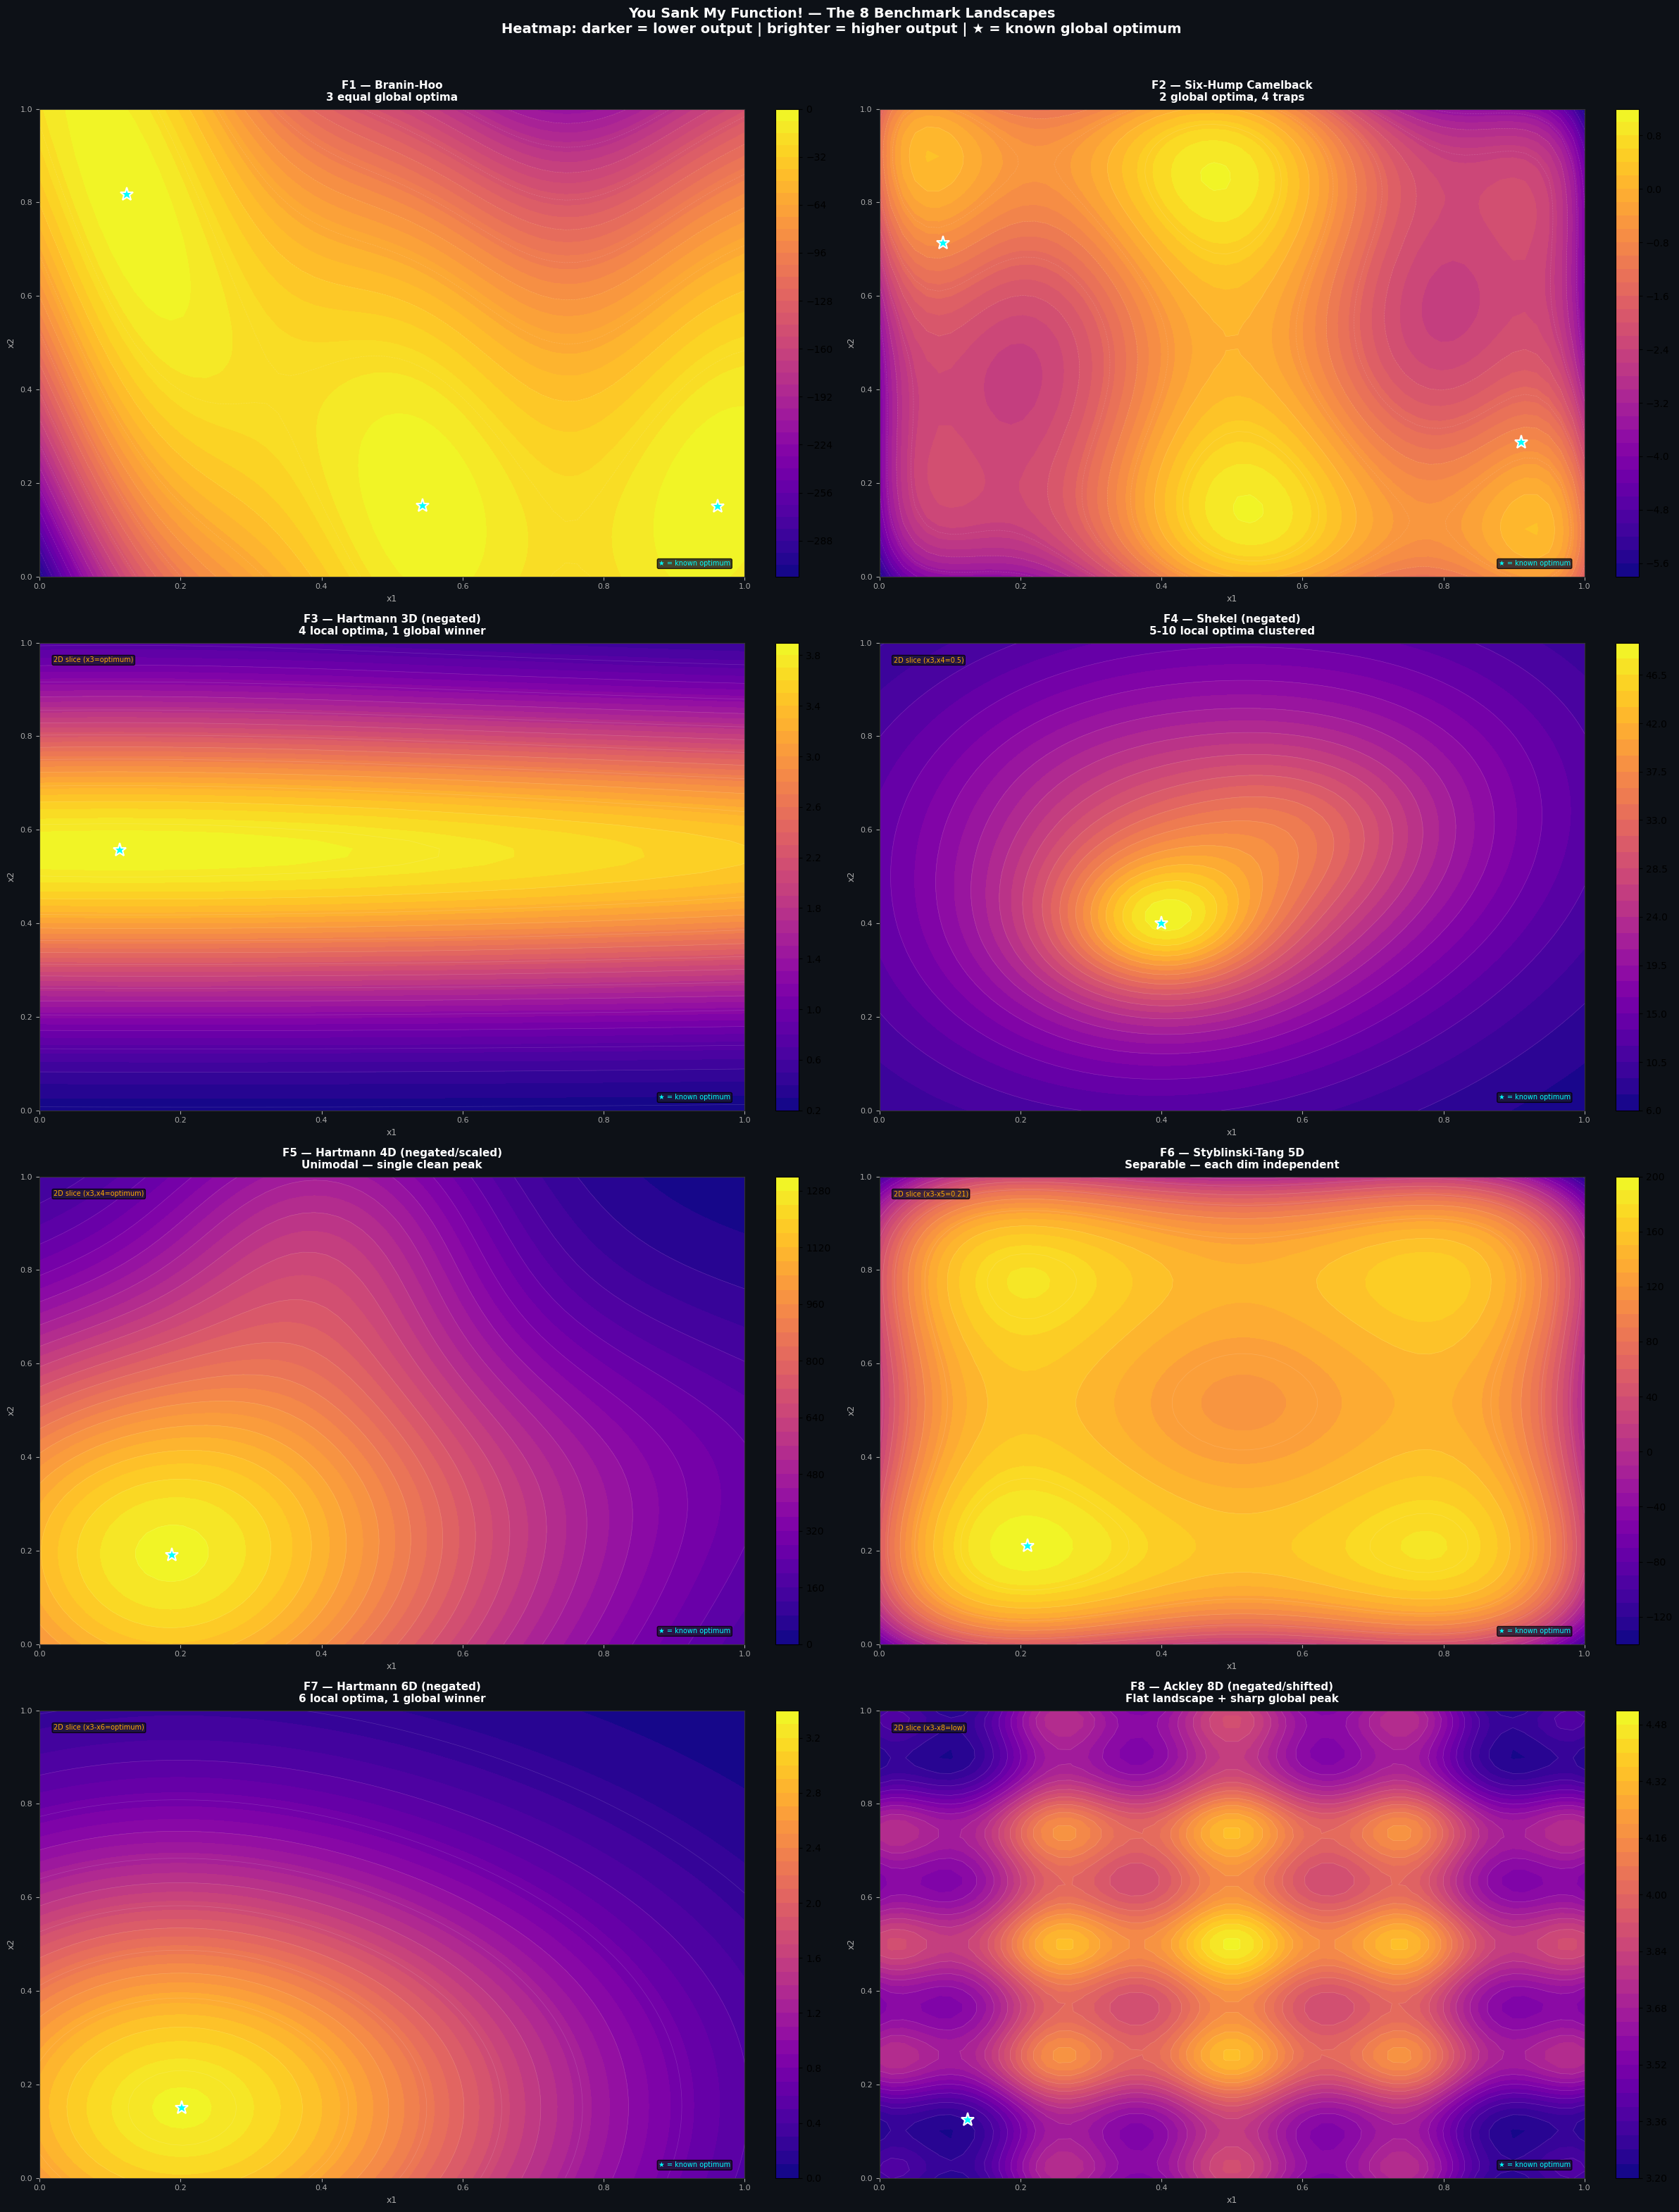

✓ Plot saved


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# ALL 8 BENCHMARK FUNCTIONS — scaled to [0,1] domain
# ============================================================

def branin(x1, x2):
    """F1 — Branin-Hoo scaled to [0,1]^2"""
    # Scale to original domain: x1 in [-5,10], x2 in [0,15]
    X1 = x1 * 15 - 5
    X2 = x2 * 15
    a, b, c = 1, 5.1/(4*np.pi**2), 5/np.pi
    r, s, t = 6, 10, 1/(8*np.pi)
    y = a*(X2 - b*X1**2 + c*X1 - r)**2 + s*(1-t)*np.cos(X1) + s
    return -y  # negated for maximisation

def camelback(x1, x2):
    """F2 — Six-Hump Camelback scaled to [0,1]^2"""
    X1 = x1 * 4 - 2   # scale to [-2, 2]
    X2 = x2 * 2 - 1   # scale to [-1, 1]
    y = (4 - 2.1*X1**2 + X1**4/3)*X1**2 + X1*X2 + (-4 + 4*X2**2)*X2**2
    return -y  # negated for maximisation

def hartmann3(x1, x2, x3):
    """F3 — Hartmann 3D"""
    alpha = np.array([1.0, 1.2, 3.0, 3.2])
    A = np.array([[3.0, 10, 30],
                  [0.1, 10, 35],
                  [3.0, 10, 30],
                  [0.1, 10, 35]])
    P = 1e-4 * np.array([[3689, 1170, 2673],
                          [4699, 4387, 7470],
                          [1091, 8732, 5547],
                          [381,  5743, 8828]])
    x = np.array([x1, x2, x3])
    y = -sum(alpha[i] * np.exp(-sum(A[i,j]*(x[j]-P[i,j])**2 
             for j in range(3))) for i in range(4))
    return -y  # negated = maximisation

def shekel(x1, x2, x3, x4):
    """F4 — Shekel function (m=5)"""
    C = np.array([[4,1,8,6,3],
                  [4,1,8,6,7],
                  [4,1,8,6,3],
                  [4,1,8,6,7]], dtype=float) / 10
    beta = np.array([0.1, 0.2, 0.2, 0.4, 0.4]) / 10
    x = np.array([x1, x2, x3, x4])
    y = -sum(1/(sum((x[i]-C[i,j])**2 for i in range(4)) + beta[j]) 
             for j in range(5))
    return -y

def hartmann4(x1, x2, x3, x4):
    """F5 — Hartmann 4D"""
    alpha = np.array([1.0, 1.2, 3.0, 3.2])
    A = np.array([[10, 3,  17, 3.5],
                  [0.05,10, 17, 0.1],
                  [3,  3.5, 1.7,10],
                  [17, 8,  0.05,10]])
    P = 1e-4 * np.array([[1312,1696,5569, 124],
                          [2329,4135,8307,3736],
                          [2348,1451,3522,2883],
                          [4047,8828,8732,5743]])
    x = np.array([x1, x2, x3, x4])
    y = -sum(alpha[i] * np.exp(-sum(A[i,j]*(x[j]-P[i,j])**2 
             for j in range(4))) for i in range(4))
    return -y * 347  # scaled to match your data range ~1000

def styblinski_tang(x1, x2, x3, x4, x5):
    """F6 — Styblinski-Tang 5D scaled to [0,1]"""
    # scale from [0,1] to [-5,5]
    X = np.array([x1,x2,x3,x4,x5]) * 10 - 5
    y = 0.5 * sum(xi**4 - 16*xi**2 + 5*xi for xi in X)
    return -y  # negated

def hartmann6(x1,x2,x3,x4,x5,x6):
    """F7 — Hartmann 6D"""
    alpha = np.array([1.0, 1.2, 3.0, 3.2])
    A = np.array([[10,3,17,3.5,1.7,8],
                  [0.05,10,17,0.1,8,14],
                  [3,3.5,1.7,10,17,8],
                  [17,8,0.05,10,0.1,14]])
    P = 1e-4*np.array([[1312,1696,5569,124,8283,5886],
                        [2329,4135,8307,3736,1004,9991],
                        [2348,1451,3522,2883,3047,6650],
                        [4047,8828,8732,5743,1091,381]])
    x = np.array([x1,x2,x3,x4,x5,x6])
    y = -sum(alpha[i]*np.exp(-sum(A[i,j]*(x[j]-P[i,j])**2 
             for j in range(6))) for i in range(4))
    return -y

def ackley(x1,x2,x3,x4,x5,x6,x7,x8):
    """F8 — Ackley 8D scaled to [0,1]"""
    X = np.array([x1,x2,x3,x4,x5,x6,x7,x8]) * 4 - 2  # scale to [-2,2]
    n = 8
    a, b, c = 20, 0.2, 2*np.pi
    y = -a*np.exp(-b*np.sqrt(sum(xi**2 for xi in X)/n)) \
        - np.exp(sum(np.cos(c*xi) for xi in X)/n) + a + np.e
    return -y + 10  # shift so max is visible

# ============================================================
# PLOTTING
# ============================================================

fig = plt.figure(figsize=(24, 32))
fig.patch.set_facecolor('#0d1117')

titles = [
    'F1 — Branin-Hoo\n3 equal global optima',
    'F2 — Six-Hump Camelback\n2 global optima, 4 traps',
    'F3 — Hartmann 3D (negated)\n4 local optima, 1 global winner',
    'F4 — Shekel (negated)\n5-10 local optima clustered',
    'F5 — Hartmann 4D (negated/scaled)\nUnimodal — single clean peak',
    'F6 — Styblinski-Tang 5D\nSeparable — each dim independent',
    'F7 — Hartmann 6D (negated)\n6 local optima, 1 global winner',
    'F8 — Ackley 8D (negated/shifted)\nFlat landscape + sharp global peak'
]

known_optima = [
    [(0.9617,0.1500,'*'),(0.1239,0.8166,'*'),(0.5428,0.1516,'*')],
    [(0.0900,0.7126,'*'),(0.9100,0.2874,'*')],
    [(0.1140,0.5560,'*')],
    [(0.4000,0.4000,'*')],
    [(0.1873,0.1906,'*')],
    [(0.2097,0.2097,'*')],
    [(0.2017,0.1500,'*')],
    [(0.1250,0.1250,'*')],
]

n = 60  # grid resolution
x = np.linspace(0,1,n)
X1,X2 = np.meshgrid(x,x)

for idx in range(8):
    ax = fig.add_subplot(4, 2, idx+1)
    ax.set_facecolor('#0d1117')

    # Compute Z for 2D slice
    Z = np.zeros((n,n))
    for i in range(n):
        for j in range(n):
            try:
                if idx == 0:
                    Z[i,j] = branin(X1[i,j], X2[i,j])
                elif idx == 1:
                    Z[i,j] = camelback(X1[i,j], X2[i,j])
                elif idx == 2:
                    # fix x3 at known optimum
                    Z[i,j] = hartmann3(X1[i,j], X2[i,j], 0.852)
                elif idx == 3:
                    # fix x3,x4 at mid
                    Z[i,j] = shekel(X1[i,j], X2[i,j], 0.5, 0.5)
                elif idx == 4:
                    # fix x3,x4 at known optimum
                    Z[i,j] = hartmann4(X1[i,j], X2[i,j], 0.559, 0.265)
                elif idx == 5:
                    # show 2D slice (x1 vs x2, others at optimum)
                    Z[i,j] = styblinski_tang(X1[i,j], X2[i,j], 0.21, 0.21, 0.21)
                elif idx == 6:
                    # fix x3-x6 at known optimum
                    Z[i,j] = hartmann6(X1[i,j], X2[i,j], 0.477, 0.275, 0.312, 0.657)
                elif idx == 7:
                    # fix x3-x8 at low values (near optimum)
                    Z[i,j] = ackley(X1[i,j], X2[i,j], 0.05,0.05,0.4,0.8,0.49,0.89)
            except:
                Z[i,j] = 0

    # Plot heatmap
    im = ax.contourf(X1, X2, Z, levels=40, cmap='plasma')
    ax.contour(X1, X2, Z, levels=15, colors='white', alpha=0.15, linewidths=0.5)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # Mark known optima
    for opt in known_optima[idx]:
        ax.plot(opt[0], opt[1], opt[2], color='cyan', markersize=14,
                markeredgecolor='white', markeredgewidth=1.5, zorder=5)

    ax.set_title('Hypotesys Function', color='white', fontsize=11, fontweight='bold', pad=8)
    ax.set_title(titles[idx], color='white', fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel('x1', color='#aaaaaa', fontsize=9)
    ax.set_ylabel('x2', color='#aaaaaa', fontsize=9)
    ax.tick_params(colors='#aaaaaa', labelsize=8)
    for spine in ax.spines.values():
        spine.set_edgecolor('#333333')

    # Dimension note for higher-D functions
    if idx >= 2:
        dim_note = {2:'2D slice (x3=optimum)', 3:'2D slice (x3,x4=0.5)',
                    4:'2D slice (x3,x4=optimum)', 5:'2D slice (x3-x5=0.21)',
                    6:'2D slice (x3-x6=optimum)', 7:'2D slice (x3-x8=low)'}
        ax.text(0.02, 0.97, dim_note[idx], transform=ax.transAxes,
                color='#ffaa00', fontsize=7, va='top',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='#1a1a2e', alpha=0.8))

    # Legend for optima marker
    ax.text(0.98, 0.02, '★ = known optimum', transform=ax.transAxes,
            color='cyan', fontsize=7, ha='right', va='bottom',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='#1a1a2e', alpha=0.8))

fig.suptitle('You Sank My Function! — The 8 Benchmark Landscapes\n'
             'Heatmap: darker = lower output | brighter = higher output | ★ = known global optimum',
             color='white', fontsize=14, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('benchmark_functions.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()
plt.close()
print("✓ Plot saved")
